# GOA Supermarket — Customer Clustering & Purchasing Behavior

**Business Analytics Project**

## Project Objective
Analyze customer purchasing behavior across a GOA Supermarket dataset containing 100 customer records to identify distinct customer segments and provide GOA Supermarket with a data-driven basis for targeted marketing and customer-retention decisions.

## Business Context
GOA Supermarket can use customer segmentation to better understand differences in income, purchase frequency, average purchase value, age, and category preference. The analysis below applies clustering techniques to identify meaningful customer groups and translate their characteristics into actionable business insights.


## Dataset Provenance

This analysis uses an **GOA Supermarket customer dataset containing 100 customer records**. The dataset represents customer-level purchasing and demographic information used for this analysis, including age, annual income, purchase frequency, average purchase value, and category preference.

The dataset is treated as **GOA Supermarket's business data** for the purpose of this project; the analysis was conducted to support GOA Supermarket's customer segmentation, targeted marketing, and customer-retention decisions.


# Import necessary libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

### Analysis Notes:

#### **Step 1: Import Necessary Libraries**

- `import pandas as pd`:
  - Imports the Pandas library for data manipulation and analysis, which is widely used for handling and analyzing data in tabular form (such as CSV files).

- `import numpy as np`:
  - Imports the NumPy library, which is used for numerical operations such as handling arrays and performing mathematical computations.

- `import matplotlib.pyplot as plt`:
  - Imports Matplotlib's `pyplot` module for creating visualizations like plots and graphs.

- `from sklearn.preprocessing import StandardScaler`:
  - Imports `StandardScaler` from `sklearn.preprocessing` to standardize features by removing the mean and scaling to unit variance. This is often done before clustering to ensure that all features contribute equally to the model.

- `from sklearn.cluster import DBSCAN, AgglomerativeClustering`:
  - Imports two clustering algorithms:
    - `DBSCAN`: A density-based clustering algorithm that groups points that are close together while marking points in low-density regions as outliers.
    - `AgglomerativeClustering`: A hierarchical clustering algorithm that merges or splits clusters based on a distance metric.

- `from sklearn.metrics import silhouette_score`:
  - Imports `silhouette_score`, a metric used to evaluate the quality of clustering. It measures how similar an object is to its own cluster compared to other clusters, with higher values indicating better-defined clusters.

- `from sklearn.decomposition import PCA`:
  - Imports `PCA` (Principal Component Analysis), a technique for reducing the dimensionality of data while preserving as much variance as possible. It is often used to visualize high-dimensional data in lower dimensions.

- `from sklearn.preprocessing import LabelEncoder`:
  - Imports `LabelEncoder` from `sklearn.preprocessing`, which is used to convert categorical labels (text values) into numeric labels, making them suitable for machine learning models.

#### **Step 2: Ignore Warnings**
- `import warnings`:
  - Imports the `warnings` module to control the display of warnings.

- `warnings.filterwarnings('ignore')`:
  - This suppresses any warnings that might arise during the execution of the code, ensuring cleaner output.

# 1. Data Cleaning and Preprocessing

In [8]:
data = pd.read_csv('/Users/mdshahriar/Downloads/Python Projects/Project 10/customer_purchase_behavior.csv')

# Check for missing values
print(data.isnull().sum())

Customer_ID            0
Age                    0
Annual_Income          0
Purchase_Frequency     0
Avg_Purchase_Value     0
Category_Preference    0
dtype: int64


### Analysis Notes:

#### **Step 1: Load the Dataset**
- `data = pd.read_csv('customer_purchase_behavior.csv')`:
  - This line loads the dataset from a CSV file located at the specified path (`'customer_purchase_behavior.csv'`) into a Pandas DataFrame (`data`).
  - The `read_csv()` function reads the CSV file and stores it in a DataFrame for further analysis.

#### **Step 2: Check for Missing Values**
- `print(data.isnull().sum())`:
  - This checks for any missing values in the dataset.
  - `isnull()` returns a DataFrame of the same shape as `data`, with `True` for missing values and `False` for non-missing values.
  - `sum()` counts the number of missing values (i.e., `True` values) in each column, providing a quick overview of where missing data might exist.

In [10]:
# Handle outliers using Z-score method for numerical columns
from scipy import stats
numerical_columns = ['Age', 'Annual_Income', 'Purchase_Frequency', 'Avg_Purchase_Value']
z_scores = np.abs(stats.zscore(data[numerical_columns]))
outliers = (z_scores > 3).all(axis=1)
data_cleaned = data[~outliers]

### Analysis Notes:

#### **Step 1: Import Required Libraries**
- `from scipy import stats`:
  - This imports the `stats` module from `scipy`, which contains various statistical functions, including the Z-score calculation used for identifying outliers.

#### **Step 2: Define Numerical Columns**
- `numerical_columns = ['Age', 'Annual_Income', 'Purchase_Frequency', 'Avg_Purchase_Value']`:
  - This defines a list of numerical columns from the dataset that will be used to detect outliers.
  - These columns are assumed to represent numerical data related to customer behavior.

#### **Step 3: Calculate Z-scores**
- `z_scores = np.abs(stats.zscore(data[numerical_columns]))`:
  - This calculates the Z-scores for each of the numerical columns.
  - `stats.zscore()` computes the Z-score, which measures how many standard deviations a data point is away from the mean.
  - `np.abs()` takes the absolute value of the Z-scores since we are interested in both positive and negative deviations.

#### **Step 4: Identify Outliers**
- `outliers = (z_scores > 3).all(axis=1)`:
  - This identifies the rows where the Z-score for all numerical columns is greater than 3.
  - A Z-score greater than 3 is often considered an outlier, as it indicates that the data point is more than 3 standard deviations away from the mean.
  - `all(axis=1)` ensures that outliers are identified when the Z-score exceeds 3 in all the numerical columns.

#### **Step 5: Remove Outliers**
- `data_cleaned = data[~outliers]`:
  - This removes the rows identified as outliers from the original dataset.
  - `~outliers` is used to negate the Boolean series, meaning we select the rows where outliers are not present.
  - The cleaned dataset, `data_cleaned`, will now have the outliers removed.



In [12]:
# Normalize or standardize the numerical variables
scaler = StandardScaler()
data_cleaned[numerical_columns] = scaler.fit_transform(data_cleaned[numerical_columns])

# Encode categorical variables into numerical formats
le = LabelEncoder()
data_cleaned['Category_Preference'] = le.fit_transform(data_cleaned['Category_Preference'])

### Analysis Notes:

#### **Step 1: Normalize or Standardize the Numerical Variables**
- `scaler = StandardScaler()`:
  - This initializes the `StandardScaler` from `sklearn.preprocessing`, which will be used to standardize the numerical variables. Standardization ensures that the variables have a mean of 0 and a standard deviation of 1.
  
- `data_cleaned[numerical_columns] = scaler.fit_transform(data_cleaned[numerical_columns])`:
  - This applies the `StandardScaler` to the numerical columns in the `data_cleaned` DataFrame.
  - `fit_transform()` first computes the mean and standard deviation for each column in `numerical_columns`, and then scales the values by subtracting the mean and dividing by the standard deviation.
  - The standardized values replace the original numerical columns in the `data_cleaned` DataFrame.

#### **Step 2: Encode Categorical Variables into Numerical Formats**
- `le = LabelEncoder()`:
  - This initializes a `LabelEncoder` from `sklearn.preprocessing`, which will be used to encode categorical labels into numerical values.

- `data_cleaned['Category_Preference'] = le.fit_transform(data_cleaned['Category_Preference'])`:
  - This applies label encoding to the `Category_Preference` column.
  - The `fit_transform()` method converts the categorical values in `Category_Preference` into numeric values, making them suitable for machine learning models.
  - Each unique category in `Category_Preference` will be assigned a unique numeric label.

# 2. Customer Segmentation with DBSCAN and Hierarchical Clustering

In [15]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(data_cleaned[numerical_columns + ['Category_Preference']])

# Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_clust.fit_predict(data_cleaned[numerical_columns + ['Category_Preference']])

### Analysis Notes:

#### **Step 1: DBSCAN Clustering**
- `dbscan = DBSCAN(eps=0.5, min_samples=5)`:
  - This initializes the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm from `sklearn.cluster`.
  - `eps=0.5` sets the maximum distance between two samples for them to be considered as in the same neighborhood.
  - `min_samples=5` specifies the minimum number of points required to form a dense region (a cluster). Any point that is not part of a dense region is considered noise.
  
- `dbscan_labels = dbscan.fit_predict(data_cleaned[numerical_columns + ['Category_Preference']])`:
  - This applies DBSCAN to the `data_cleaned` DataFrame.
  - `fit_predict()` fits the model to the data and assigns a cluster label to each data point.
  - The input data includes the numerical columns and the encoded `Category_Preference` column, which are used to determine the clusters.
  - `dbscan_labels` contains the cluster labels for each data point, with noise points labeled as `-1`.

#### **Step 2: Agglomerative Clustering**
- `agg_clust = AgglomerativeClustering(n_clusters=3)`:
  - This initializes the Agglomerative Clustering algorithm from `sklearn.cluster`.
  - `n_clusters=3` specifies that the data should be divided into 3 clusters using a hierarchical clustering approach.

- `agg_labels = agg_clust.fit_predict(data_cleaned[numerical_columns + ['Category_Preference']])`:
  - This applies Agglomerative Clustering to the `data_cleaned` DataFrame.
  - `fit_predict()` fits the model to the data and assigns a cluster label to each data point based on the hierarchical clustering approach.
  - The input data includes the numerical columns and the encoded `Category_Preference` column.
  - `agg_labels` contains the cluster labels for each data point.



# 3. Determining the Number of Customer Segments

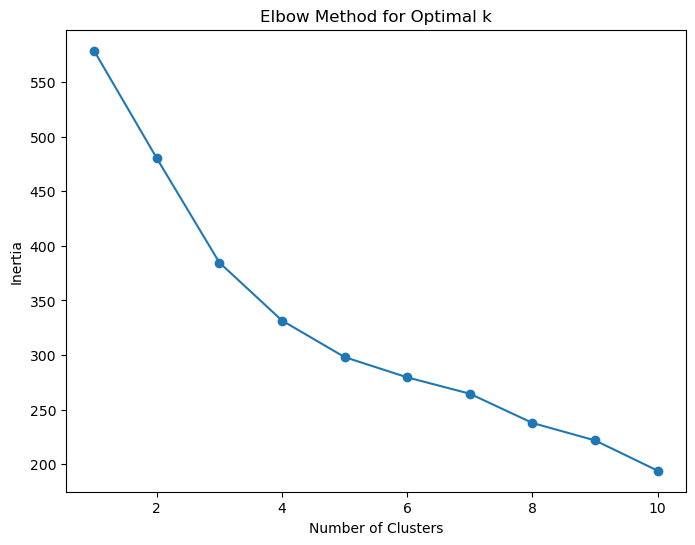

In [18]:
# Elbow Method for Agglomerative Clustering (not applicable for DBSCAN)
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_cleaned[numerical_columns + ['Category_Preference']])
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### Analysis Notes:

#### **Step 1: Import KMeans for Elbow Method**
- `from sklearn.cluster import KMeans`:
  - This imports the KMeans algorithm from `sklearn.cluster`, which is used for performing K-means clustering.
  - The Elbow Method is commonly used with KMeans to determine the optimal number of clusters.

#### **Step 2: Apply the Elbow Method to Find Optimal k**
- `inertia = []`:
  - This initializes an empty list `inertia` to store the inertia values (sum of squared distances of samples to their closest cluster center) for each number of clusters `k`.

- `for k in range(1, 11):`:
  - This loop iterates over a range of values for `k` (from 1 to 10), representing the number of clusters to evaluate.
  
- `kmeans = KMeans(n_clusters=k, random_state=42)`:
  - For each value of `k`, this initializes a KMeans model with `k` clusters.
  - `random_state=42` ensures the clustering results are reproducible.

- `kmeans.fit(data_cleaned[numerical_columns + ['Category_Preference']])`:
  - This fits the KMeans model to the `data_cleaned` dataset, using the numerical columns and the `Category_Preference` column (encoded as a numerical variable).
  
- `inertia.append(kmeans.inertia_)`:
  - The inertia for the current clustering is calculated using `kmeans.inertia_` and added to the `inertia` list. Inertia measures the compactness of the clusters, with lower values indicating tighter clusters.

#### **Step 3: Plot the Elbow Curve**
- `plt.figure(figsize=(8, 6))`:
  - This sets the figure size of the plot to 8 inches wide by 6 inches tall for clarity.

- `plt.plot(range(1, 11), inertia, marker='o')`:
  - This plots the inertia values against the number of clusters (`k` values) from 1 to 10.
  - The `marker='o'` argument adds markers to the plot at each point for better visualization.

- `plt.title("Elbow Method for Optimal k")`:
  - This sets the title of the plot, indicating that the elbow method is being used to find the optimal number of clusters.

- `plt.xlabel("Number of Clusters")`:
  - This labels the x-axis as "Number of Clusters", representing the values of `k` being tested.

- `plt.ylabel("Inertia")`:
  - This labels the y-axis as "Inertia", representing the compactness of the clusters for each value of `k`.

- `plt.show()`:
  - This displays the plot in the Jupyter notebook.



# 4. Customer Segment Analysis

In [24]:
# Analyze the resulting clusters (mean of variables)
data_cleaned['DBSCAN_Cluster'] = dbscan_labels
data_cleaned['Agglomerative_Cluster'] = agg_labels

# Grouping by clusters to analyze characteristics
agg_cluster_analysis = data_cleaned.groupby('Agglomerative_Cluster').mean()
dbscan_cluster_analysis = data_cleaned.groupby('DBSCAN_Cluster').mean()

print("Agglomerative Clustering Cluster Analysis")
print(agg_cluster_analysis)

print("DBSCAN Cluster Analysis")
print(dbscan_cluster_analysis)

Agglomerative Clustering Cluster Analysis
                       Customer_ID       Age  Annual_Income  \
Agglomerative_Cluster                                         
0                        53.085714  0.169059      -0.198475   
1                        45.242424 -0.342366      -0.753637   
2                        53.093750  0.168156       0.994270   

                       Purchase_Frequency  Avg_Purchase_Value  \
Agglomerative_Cluster                                           
0                                0.242201            0.128190   
1                               -0.313931            0.216458   
2                                0.058834           -0.363430   

                       Category_Preference  DBSCAN_Cluster  
Agglomerative_Cluster                                       
0                                 3.257143            -1.0  
1                                 0.727273            -1.0  
2                                 1.375000            -1.0  
DBSCAN Clus

### Analysis Notes:

#### **Step 1: Assign Cluster Labels to Data**
- `data_cleaned['DBSCAN_Cluster'] = dbscan_labels`:
  - This assigns the cluster labels generated by DBSCAN (`dbscan_labels`) to a new column `DBSCAN_Cluster` in the `data_cleaned` DataFrame.
  - Each data point is labeled with its respective cluster based on DBSCAN results.

- `data_cleaned['Agglomerative_Cluster'] = agg_labels`:
  - This assigns the cluster labels generated by Agglomerative Clustering (`agg_labels`) to a new column `Agglomerative_Cluster` in the `data_cleaned` DataFrame.
  - Each data point is labeled with its respective cluster based on Agglomerative Clustering results.

#### **Step 2: Group Data by Clusters and Analyze Characteristics**
- `agg_cluster_analysis = data_cleaned.groupby('Agglomerative_Cluster').mean()`:
  - This groups the `data_cleaned` DataFrame by the `Agglomerative_Cluster` column and calculates the mean of the numerical variables for each cluster.
  - This analysis provides insights into the characteristics of each cluster formed by Agglomerative Clustering.

- `dbscan_cluster_analysis = data_cleaned.groupby('DBSCAN_Cluster').mean()`:
  - This groups the `data_cleaned` DataFrame by the `DBSCAN_Cluster` column and calculates the mean of the numerical variables for each DBSCAN cluster.
  - The analysis helps understand the characteristics of each cluster formed by DBSCAN.

#### **Step 3: Print Cluster Analysis Results**
- `print("Agglomerative Clustering Cluster Analysis")`:
  - This prints a message indicating that the following results are related to Agglomerative Clustering.

- `print(agg_cluster_analysis)`:
  - This prints the mean values of numerical variables for each cluster in Agglomerative Clustering, showing the characteristics of the clusters.

- `print("DBSCAN Cluster Analysis")`:
  - This prints a message indicating that the following results are related to DBSCAN clustering.

- `print(dbscan_cluster_analysis)`:
  - This prints the mean values of numerical variables for each cluster in DBSCAN, showing the characteristics of the clusters.



# 5. Visualization of Customer Segments

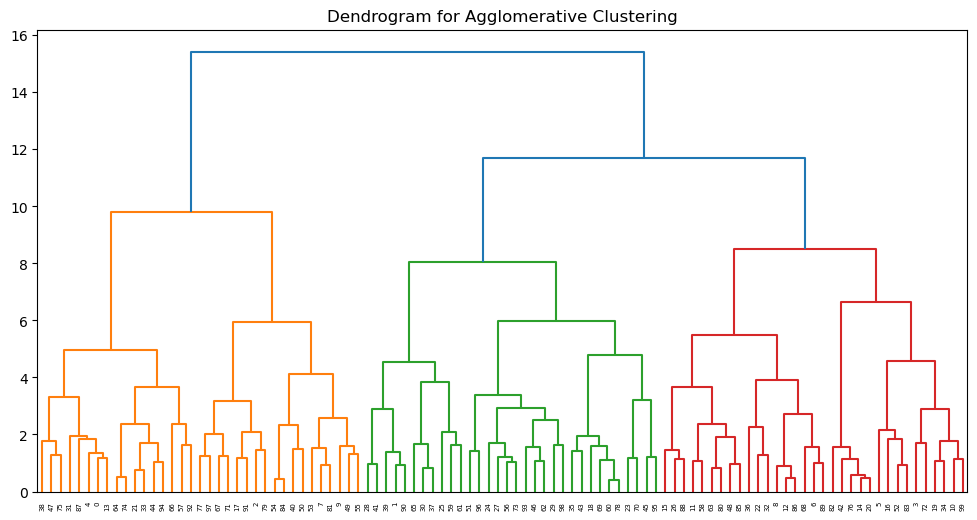

In [35]:
# 6.2 Create dendrogram for Agglomerative Clustering
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 6))
sch.dendrogram(sch.linkage(data_cleaned[numerical_columns + ['Category_Preference']], method='ward'))
plt.title('Dendrogram for Agglomerative Clustering')
plt.show()

### Analysis Notes:

#### **Step 1: Import Required Libraries**
- `import scipy.cluster.hierarchy as sch`:
  - This imports the `hierarchy` module from `scipy.cluster`, which provides tools for hierarchical clustering, including the `dendrogram` function used to visualize the cluster hierarchy.

#### **Step 2: Create a Dendrogram for Agglomerative Clustering**
- `plt.figure(figsize=(12, 6))`:
  - This sets the figure size of the plot to 12 inches wide by 6 inches tall, ensuring that the dendrogram is displayed clearly and is easy to interpret.

- `sch.dendrogram(sch.linkage(data_cleaned[numerical_columns + ['Category_Preference']], method='ward'))`:
  - This creates a dendrogram to visualize the hierarchical clustering process.
  - `sch.linkage()` performs hierarchical clustering using the specified method (`'ward'` in this case), which minimizes the variance of the clusters at each step.
  - `data_cleaned[numerical_columns + ['Category_Preference']]` specifies the data to be used for clustering, including the numerical columns and the encoded `Category_Preference` column.
  - `sch.dendrogram()` takes the linkage matrix generated by `linkage()` and creates a visual representation of the clustering process.

#### **Step 3: Add Title and Display the Dendrogram**
- `plt.title('Dendrogram for Agglomerative Clustering')`:
  - This sets the title of the plot, indicating that the dendrogram represents the results of Agglomerative Clustering.

- `plt.show()`:
  - This displays the dendrogram in the Jupyter notebook.

# Project Summary

The analysis identified **three customer segments** using hierarchical clustering and examined segment-level differences in income, purchase frequency, average purchase value, age, and category preference. These findings provide GOA Supermarket with a structured basis for differentiated marketing, customer engagement, and retention planning.

**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Jupyter Notebook
